# Electricity Anomaly Detection — EDA

**Stage 0.1** — Global Dataset EDA  
**Stage 0.2** — Site-Level Profiling

Dataset: Building Data Genome Project 2  
Input files:
- `electricity_cleaned.csv` — wide format, one column per building
- `metadata.csv` — building-level attributes

No files are exported. All output is displayed inline.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../data/building-data-genome-project-2/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'

---
# Stage 0.1 — Global Dataset EDA

## 1. Dataset Structure

In [2]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']

print(f'Shape              : {elec.shape}')
print(f'Timestamps         : {elec.shape[0]:,}')
print(f'Building columns   : {len(building_cols):,}')

Shape              : (17544, 1579)
Timestamps         : 17,544
Building columns   : 1,578


In [3]:
display(elec[['timestamp'] + building_cols[:6]].head())

,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dtype_counts = elec[building_cols].dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
print('Electricity column dtypes:')
display(dtype_counts)

Electricity column dtypes:


,dtype,count
0,float64,1578


## 2. Timestamp Analysis

In [5]:
ts = elec['timestamp']
t_min, t_max = ts.min(), ts.max()
duration_days = (t_max - t_min).total_seconds() / 86400
diffs = ts.diff().dropna()
freq_mode = diffs.mode()[0]
expected_hourly = pd.Timedelta('1h')
non_hourly = (diffs != expected_hourly).sum()
gaps = diffs[diffs > expected_hourly]
n_duplicates = ts.duplicated().sum()

print(f'Earliest timestamp : {t_min}')
print(f'Latest timestamp   : {t_max}')
print(f'Duration           : {duration_days:.1f} days')
print(f'Most common freq   : {freq_mode}')
print(f'Is hourly (mode)   : {freq_mode == expected_hourly}')
print(f'Non-hourly steps   : {non_hourly:,}')
print(f'Gaps > 1 h         : {len(gaps):,}')
print(f'Duplicate timestamps: {n_duplicates:,}')

if len(gaps) > 0:
    print('\nLargest gaps:')
    gap_df = pd.DataFrame({'gap_start': ts[gaps.index - 1].values,
                           'gap_hours': (gaps / pd.Timedelta('1h')).values})
    display(gap_df.nlargest(10, 'gap_hours').reset_index(drop=True))

Earliest timestamp : 2016-01-01 00:00:00
Latest timestamp   : 2017-12-31 23:00:00
Duration           : 731.0 days
Most common freq   : 0 days 01:00:00
Is hourly (mode)   : True
Non-hourly steps   : 0
Gaps > 1 h         : 0
Duplicate timestamps: 0


## 3. Overall Missing Data

In [6]:
n_ts   = len(elec)
n_bld  = len(building_cols)
total_possible = n_ts * n_bld
total_missing  = elec[building_cols].isna().sum().sum()
overall_rate   = total_missing / total_possible

print(f'Total possible readings : {total_possible:,}')
print(f'Total missing readings  : {total_missing:,}')
print(f'Overall missing rate    : {overall_rate:.2%}')

Total possible readings : 27,684,432
Total missing readings  : 2,471,853
Overall missing rate    : 8.93%


In [7]:
elec_tmp = elec.set_index('timestamp')
missing_ts = elec_tmp[building_cols].isna().mean(axis=1)  # fraction of buildings missing per timestamp
missing_monthly = missing_ts.resample('ME').mean().rename('missing_rate')
missing_monthly.index = missing_monthly.index.to_period('M').astype(str)

ym_df = missing_monthly.reset_index()
ym_df.columns = ['year_month', 'missing_rate']
ym_df['year']  = ym_df['year_month'].str[:4]
ym_df['month'] = ym_df['year_month'].str[5:7]

print('Missing rate by year-month (fraction of building readings missing):')
display(ym_df.pivot(index='year', columns='month', values='missing_rate').style.format('{:.2%}'))

Missing rate by year-month (fraction of building readings missing):


month,01,02,03,04,05,06,07,08,09,10,11,12
year,,,,,,,,,,,,
2016,12.93%,17.41%,19.12%,12.57%,10.55%,6.55%,8.39%,7.45%,6.21%,8.08%,6.71%,8.38%
2017,7.12%,6.74%,7.44%,6.87%,8.48%,9.47%,7.40%,6.81%,6.66%,7.22%,7.82%,7.96%


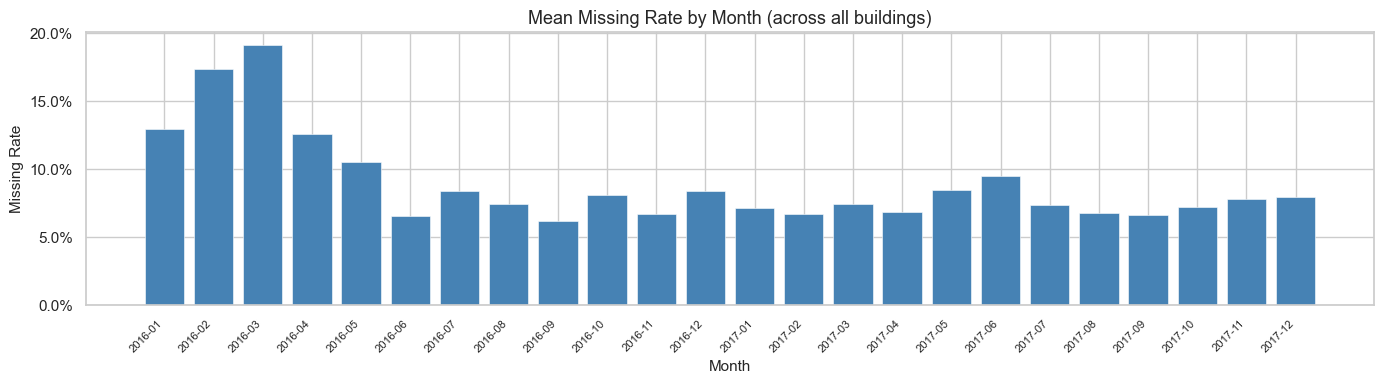

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(ym_df)), ym_df['missing_rate'], color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(ym_df)))
ax.set_xticklabels(ym_df['year_month'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Mean Missing Rate by Month (across all buildings)')
ax.set_xlabel('Month')
ax.set_ylabel('Missing Rate')
plt.tight_layout()
plt.show()

## 4. Overall Consumption Statistics

In [9]:
# Stack column-by-column to avoid loading all values at once
chunk_stats = []
for col in building_cols:
    s = elec[col].dropna().values
    if len(s):
        chunk_stats.append(s)

all_vals = np.concatenate(chunk_stats)

pcts = np.percentile(all_vals, [1, 5, 25, 50, 75, 95, 99])
stats_dict = {
    'count' : len(all_vals),
    'mean'  : float(all_vals.mean()),
    'median': float(np.median(all_vals)),
    'std'   : float(all_vals.std()),
    'min'   : float(all_vals.min()),
    'p1'    : pcts[0],
    'p5'    : pcts[1],
    'p25'   : pcts[2],
    'p75'   : pcts[4],
    'p95'   : pcts[5],
    'p99'   : pcts[6],
    'max'   : float(all_vals.max()),
}
display(pd.DataFrame.from_dict(stats_dict, orient='index', columns=['value']).rename_axis('statistic'))
del chunk_stats

,value
statistic,
count,2.521258e+07
mean,1.449146e+02
median,5.957000e+01
std,2.688494e+02
min,1.000000e-04
p1,4.000000e-04
p5,1.440000e+00
p25,1.937500e+01
p75,1.568667e+02


## 5. Negative Values

In [10]:
neg_counts = (elec[building_cols] < 0).sum()
n_neg_total = neg_counts.sum()
n_valid = elec[building_cols].count().sum()
print(f'Total negative readings : {n_neg_total:,}')
print(f'Negative rate           : {n_neg_total / n_valid:.4%}')
print(f'Buildings with negatives: {(neg_counts > 0).sum():,}')

top_neg = neg_counts[neg_counts > 0].sort_values(ascending=False).head(20)
if len(top_neg):
    print('\nTop buildings by negative count:')
    display(top_neg.rename('negative_count').to_frame())

Total negative readings : 0
Negative rate           : 0.0000%
Buildings with negatives: 0


## 6. Zero Values

In [11]:
zero_counts = (elec[building_cols] == 0).sum()
n_zero_total = zero_counts.sum()
print(f'Total zero readings : {n_zero_total:,}')
print(f'Zero rate           : {n_zero_total / n_valid:.4%}')

Total zero readings : 0
Zero rate           : 0.0000%


## 7. Extreme Values

In [12]:
p99   = np.percentile(all_vals, 99)
p999  = np.percentile(all_vals, 99.9)
print(f'Global p99   threshold : {p99:.3f}')
print(f'Global p99.9 threshold : {p999:.3f}')

# Top 20 readings
records = []
for col in building_cols:
    col_max = elec[col].max()
    if pd.notna(col_max):
        records.append((col, col_max))

top20_bld = sorted(records, key=lambda x: x[1], reverse=True)[:20]
top20_rows = []
for bld, _ in top20_bld:
    idx = elec[bld].idxmax()
    top20_rows.append({'building_id': bld, 'timestamp': elec.loc[idx, 'timestamp'], 'value': elec.loc[idx, bld]})

display(pd.DataFrame(top20_rows).sort_values('value', ascending=False).reset_index(drop=True))

Global p99   threshold : 1244.320
Global p99.9 threshold : 2626.808


,building_id,timestamp,value
0,Bull_education_Dottie,2017-09-06 15:00:00,221228.0000
1,Bull_education_Delia,2017-11-27 12:00:00,55077.0000
2,Hog_office_Nia,2016-03-30 09:00:00,44336.4610
3,Bull_education_Jeffery,2016-10-17 07:00:00,30268.0000
4,Swan_unknown_Rocco,2017-03-15 16:00:00,18845.7369
5,Swan_unknown_Jerold,2017-01-24 08:00:00,14030.6778
6,Bull_lodging_Travis,2017-10-03 01:00:00,12576.0000
7,Bull_assembly_Nick,2016-02-26 08:00:00,11624.0000
8,Bull_education_Barry,2016-12-10 15:00:00,11019.0000
9,Bull_assembly_Lance,2016-03-30 01:00:00,10725.0000


## 8. Temporal Consumption Patterns

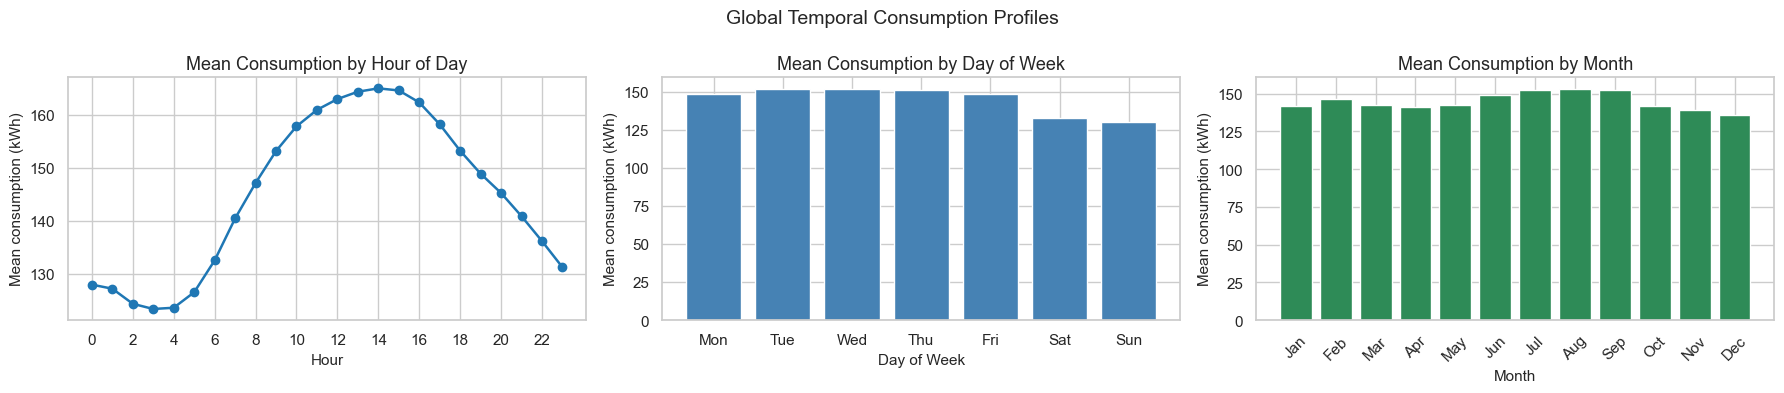

In [13]:
# Row-mean across buildings (memory-friendly)
elec_idx = elec.set_index('timestamp')
row_mean = elec_idx[building_cols].mean(axis=1)

hourly_profile  = row_mean.groupby(row_mean.index.hour).mean()
dow_profile     = row_mean.groupby(row_mean.index.dayofweek).mean()
monthly_profile = row_mean.groupby(row_mean.index.month).mean()

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hourly_profile.index, hourly_profile.values, marker='o', linewidth=1.8)
axes[0].set_title('Mean Consumption by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean consumption (kWh)')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(dow_profile.index, dow_profile.values, color='steelblue', edgecolor='white')
axes[1].set_title('Mean Consumption by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean consumption (kWh)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)

axes[2].bar(monthly_profile.index, monthly_profile.values, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Consumption by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean consumption (kWh)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=45)

plt.suptitle('Global Temporal Consumption Profiles', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Metadata Overview

In [14]:
meta = pd.read_csv(META_PATH)
print(f'Metadata shape  : {meta.shape}')
print(f'Metadata columns: {list(meta.columns)}')

Metadata shape  : (1636, 32)
Metadata columns: ['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']


In [15]:
elec_bld_set  = set(building_cols)
meta_bld_set  = set(meta['building_id'].dropna())
matched   = elec_bld_set & meta_bld_set
unmatched_elec = elec_bld_set - meta_bld_set
unmatched_meta = meta_bld_set - elec_bld_set

print(f'Buildings in electricity data : {len(elec_bld_set):,}')
print(f'Buildings in metadata         : {len(meta_bld_set):,}')
print(f'Matched (both datasets)       : {len(matched):,}')
print(f'In electricity, not metadata  : {len(unmatched_elec):,}')
print(f'In metadata, not electricity  : {len(unmatched_meta):,}')

Buildings in electricity data : 1,578
Buildings in metadata         : 1,636
Matched (both datasets)       : 1,578
In electricity, not metadata  : 0
In metadata, not electricity  : 58


In [16]:
site_counts  = meta['site_id'].value_counts().rename_axis('site_id').reset_index(name='building_count')
usage_counts = meta['primaryspaceusage'].value_counts().rename_axis('usage').reset_index(name='building_count')

print('Building count by site_id:')
display(site_counts)
print('\nBuilding count by primaryspaceusage:')
display(usage_counts)

Building count by site_id:


,site_id,building_count
0,Rat,305
1,Hog,163
2,Lamb,147
3,Fox,137
4,Panther,136
5,Bull,124
6,Cockatoo,124
7,Eagle,106
8,Bear,92
9,Gator,74



Building count by primaryspaceusage:


,usage,building_count
0,Education,617
1,Office,307
2,Entertainment/public assembly,204
3,Lodging/residential,168
4,Public services,166
5,Other,29
6,Healthcare,29
7,Parking,24
8,Warehouse/storage,15
9,Manufacturing/industrial,13


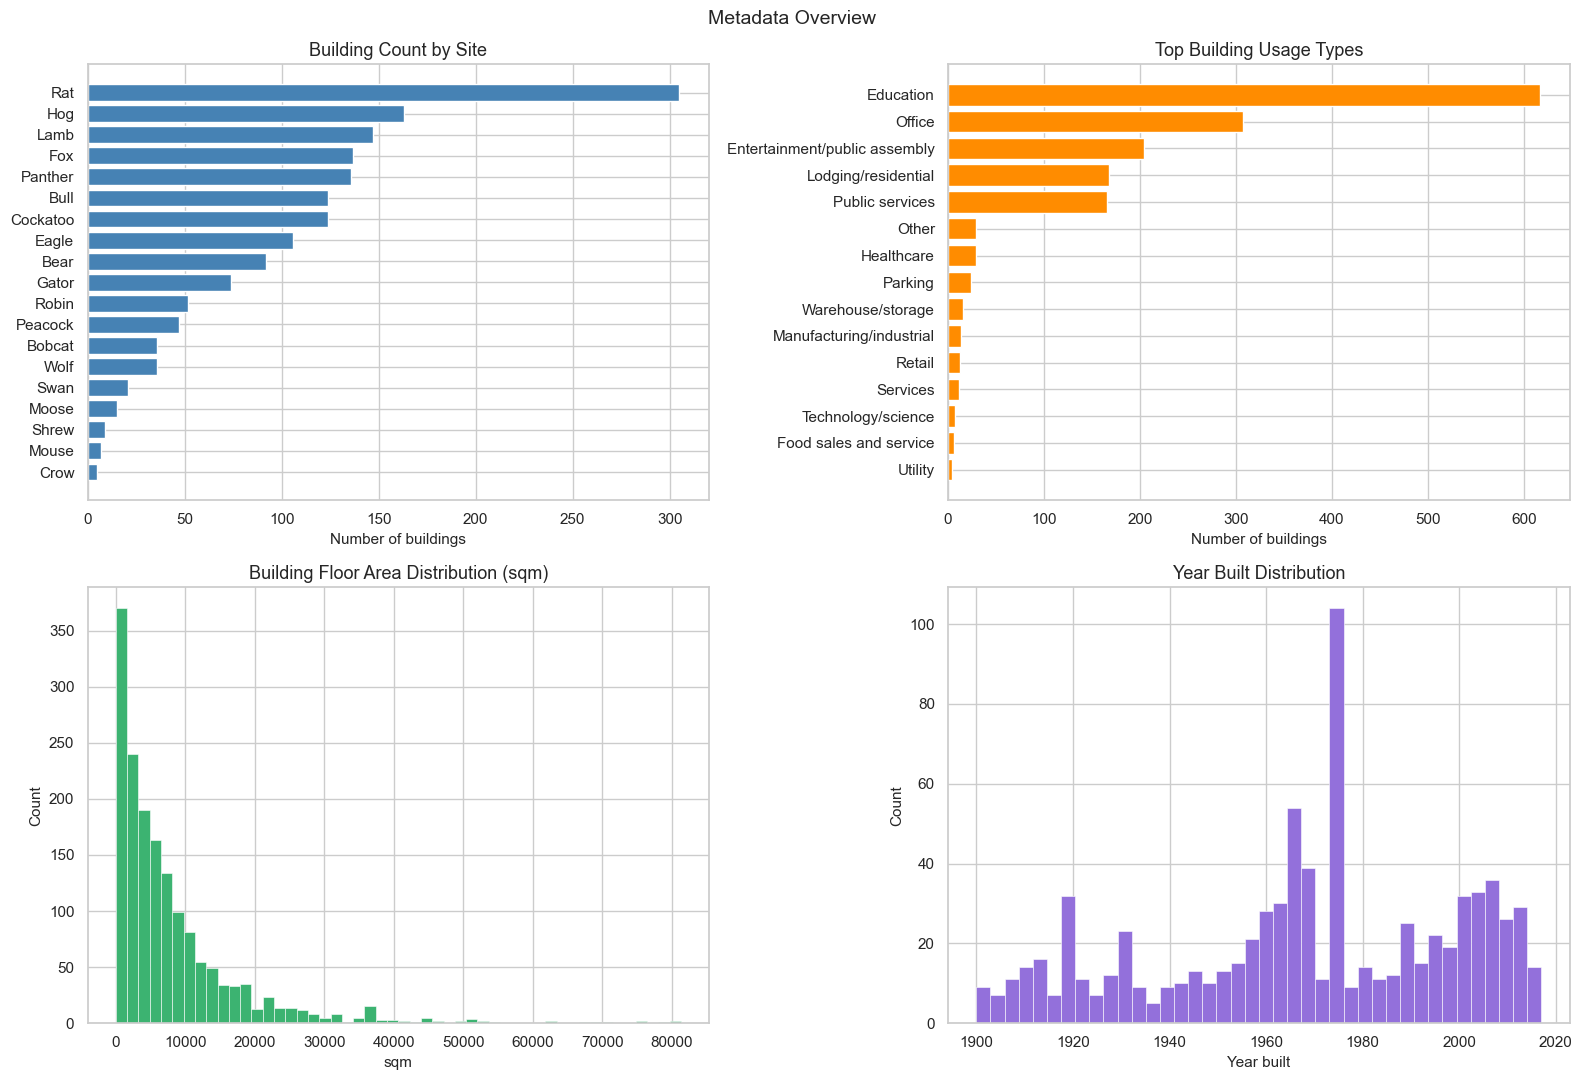

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Site building count
axes[0, 0].barh(site_counts['site_id'], site_counts['building_count'], color='steelblue')
axes[0, 0].set_title('Building Count by Site')
axes[0, 0].set_xlabel('Number of buildings')
axes[0, 0].invert_yaxis()

# Top usage types
top_usage = usage_counts.head(15)
axes[0, 1].barh(top_usage['usage'], top_usage['building_count'], color='darkorange')
axes[0, 1].set_title('Top Building Usage Types')
axes[0, 1].set_xlabel('Number of buildings')
axes[0, 1].invert_yaxis()

# sqm distribution
sqm_vals = meta['sqm'].dropna()
axes[1, 0].hist(sqm_vals, bins=50, edgecolor='white', linewidth=0.4, color='mediumseagreen')
axes[1, 0].set_title('Building Floor Area Distribution (sqm)')
axes[1, 0].set_xlabel('sqm')
axes[1, 0].set_ylabel('Count')

# yearbuilt distribution
yb_vals = meta['yearbuilt'].dropna()
axes[1, 1].hist(yb_vals, bins=40, edgecolor='white', linewidth=0.4, color='mediumpurple')
axes[1, 1].set_title('Year Built Distribution')
axes[1, 1].set_xlabel('Year built')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Metadata Overview', fontsize=14)
plt.tight_layout()
plt.show()

### Stage 0.1 — Summary Observations

*(Fill in after reviewing outputs above.)*

- **Dataset coverage**: ...
- **Missing data**: ...
- **Negative / zero values**: ...
- **Extreme values**: ...
- **Temporal patterns**: ...
- **Metadata coverage**: ...

---
# Stage 0.2 — Site-Level Profiling

## 1. Prepare Electricity + Metadata Relationship

In [18]:
# Only buildings present in both datasets
meta_elec = meta[meta['building_id'].isin(building_cols)][['building_id', 'site_id']].copy()
bld_to_site = meta_elec.set_index('building_id')['site_id'].to_dict()

# site -> list of building columns
from collections import defaultdict
site_to_blds = defaultdict(list)
for bld, site in bld_to_site.items():
    site_to_blds[site].append(bld)
site_to_blds = dict(site_to_blds)

sites = sorted(site_to_blds.keys())
print(f'Sites with electricity data: {len(sites)}')
print(f'Sites: {sites}')

Sites with electricity data: 19
Sites: ['Bear', 'Bobcat', 'Bull', 'Cockatoo', 'Crow', 'Eagle', 'Fox', 'Gator', 'Hog', 'Lamb', 'Moose', 'Mouse', 'Panther', 'Peacock', 'Rat', 'Robin', 'Shrew', 'Swan', 'Wolf']


## 2. Site Size Profile

In [19]:
total_blds = sum(len(v) for v in site_to_blds.values())
size_df = pd.DataFrame([
    {'site_id': s, 'n_buildings': len(site_to_blds[s]),
     'pct_total': len(site_to_blds[s]) / total_blds * 100}
    for s in sites
]).sort_values('n_buildings', ascending=False).reset_index(drop=True)

display(size_df.style.format({'pct_total': '{:.1f}%'}))

,site_id,n_buildings,pct_total
0,Rat,305,19.3%
1,Hog,152,9.6%
2,Lamb,146,9.3%
3,Fox,137,8.7%
4,Bull,123,7.8%
5,Cockatoo,117,7.4%
6,Eagle,106,6.7%
7,Panther,105,6.7%
8,Bear,92,5.8%
9,Gator,74,4.7%


## 3. Site Consumption Profile

In [20]:
def site_consumption_stats(site):
    cols = site_to_blds[site]
    vals = elec[cols].values.ravel()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return {}
    return {
        'site_id'  : site,
        'total'    : vals.sum(),
        'mean'     : vals.mean(),
        'median'   : np.median(vals),
        'std'      : vals.std(),
        'min'      : vals.min(),
        'max'      : vals.max(),
        'p95'      : np.percentile(vals, 95),
        'p99'      : np.percentile(vals, 99),
    }

cons_df = pd.DataFrame([site_consumption_stats(s) for s in sites])
cons_df.sort_values('total', ascending=False, inplace=True)
cons_df.reset_index(drop=True, inplace=True)

display(cons_df.style.format({c: '{:,.2f}' for c in cons_df.columns if c != 'site_id'}))

,site_id,total,mean,median,std,min,max,p95,p99
0,Hog,"608,160,782.68",243.00,107.00,441.77,0.01,"44,336.46",932.58,"2,350.73"
1,Rat,"574,271,756.54",117.03,46.02,241.87,0.01,"3,095.44",471.73,"1,331.04"
2,Bull,"386,911,222.31",185.88,95.00,326.60,0.24,"221,228.00",634.00,"1,074.00"
3,Fox,"361,063,711.67",152.83,86.37,259.59,0.01,"3,193.57",495.31,"1,014.61"
4,Eagle,"339,017,593.60",196.25,105.12,236.40,0.27,"1,989.07",642.76,"1,290.75"
5,Bear,"277,828,976.22",179.60,70.50,284.93,0.01,"2,343.47",775.45,"1,455.52"
6,Cockatoo,"247,124,714.00",135.39,78.38,177.84,0.03,"1,374.17",469.23,896.38
7,Panther,"158,325,765.77",107.18,64.00,123.27,0.02,"1,324.97",402.80,586.95
8,Robin,"143,008,433.61",158.56,85.00,181.22,0.01,"1,544.50",521.20,839.50
9,Moose,"126,448,438.61",630.00,450.91,569.95,0.00,"4,861.70","1,561.36","1,998.74"


## 4. Site Data Quality Profile

In [21]:
def site_quality_stats(site):
    cols = site_to_blds[site]
    sub  = elec[cols]
    total    = sub.size
    missing  = sub.isna().sum().sum()
    zero     = (sub == 0).sum().sum()
    negative = (sub < 0).sum().sum()
    valid    = total - missing
    return {
        'site_id'       : site,
        'total_readings': total,
        'missing'       : missing,
        'missing_rate'  : missing / total if total else np.nan,
        'zeros'         : zero,
        'zero_rate'     : zero / valid if valid else np.nan,
        'negatives'     : negative,
        'negative_rate' : negative / valid if valid else np.nan,
    }

qual_df = pd.DataFrame([site_quality_stats(s) for s in sites])
qual_df.sort_values('missing_rate', ascending=False, inplace=True)
qual_df.reset_index(drop=True, inplace=True)

fmt = {c: '{:.2%}' for c in ['missing_rate', 'zero_rate', 'negative_rate']}
fmt.update({c: '{:,}' for c in ['total_readings', 'missing', 'zeros', 'negatives']})
display(qual_df.style.format(fmt))

,site_id,total_readings,missing,missing_rate,zeros,zero_rate,negatives,negative_rate
0,Swan,"333,336","174,155",52.25%,0,0.00%,0,0.00%
1,Shrew,"157,896","72,040",45.62%,0,0.00%,0,0.00%
2,Bobcat,"614,040","174,622",28.44%,0,0.00%,0,0.00%
3,Mouse,"122,808","30,241",24.62%,0,0.00%,0,0.00%
4,Panther,"1,842,120","364,968",19.81%,0,0.00%,0,0.00%
5,Gator,"1,298,256","175,133",13.49%,0,0.00%,0,0.00%
6,Peacock,"789,480","98,227",12.44%,0,0.00%,0,0.00%
7,Moose,"228,072","27,360",12.00%,0,0.00%,0,0.00%
8,Cockatoo,"2,052,648","227,314",11.07%,0,0.00%,0,0.00%
9,Rat,"5,350,920","443,728",8.29%,0,0.00%,0,0.00%


## 5. Site Variability Profile

In [22]:
var_df = cons_df[['site_id', 'mean', 'std']].copy()
var_df['cv'] = var_df['std'] / var_df['mean']
var_df.sort_values('cv', ascending=False, inplace=True)
var_df.reset_index(drop=True, inplace=True)

display(var_df.style.format({'mean': '{:.3f}', 'std': '{:.3f}', 'cv': '{:.3f}'}))

,site_id,mean,std,cv
0,Gator,72.990,228.251,3.127
1,Lamb,18.110,47.073,2.599
2,Rat,117.027,241.871,2.067
3,Hog,243.002,441.769,1.818
4,Bull,185.884,326.597,1.757
5,Fox,152.834,259.586,1.698
6,Bear,179.596,284.931,1.587
7,Cockatoo,135.386,177.841,1.314
8,Peacock,182.456,234.589,1.286
9,Eagle,196.248,236.405,1.205


## 6. Site Temporal Profiles

In [23]:
def site_profile_by(site, groupby_fn):
    """Return mean consumption for a site grouped by groupby_fn(timestamp)."""
    cols = site_to_blds[site]
    site_mean = elec_idx[cols].mean(axis=1)
    return site_mean.groupby(groupby_fn(site_mean.index)).mean()

hourly_profiles  = {s: site_profile_by(s, lambda idx: idx.hour)        for s in sites}
dow_profiles     = {s: site_profile_by(s, lambda idx: idx.dayofweek)   for s in sites}
monthly_profiles = {s: site_profile_by(s, lambda idx: idx.month)       for s in sites}

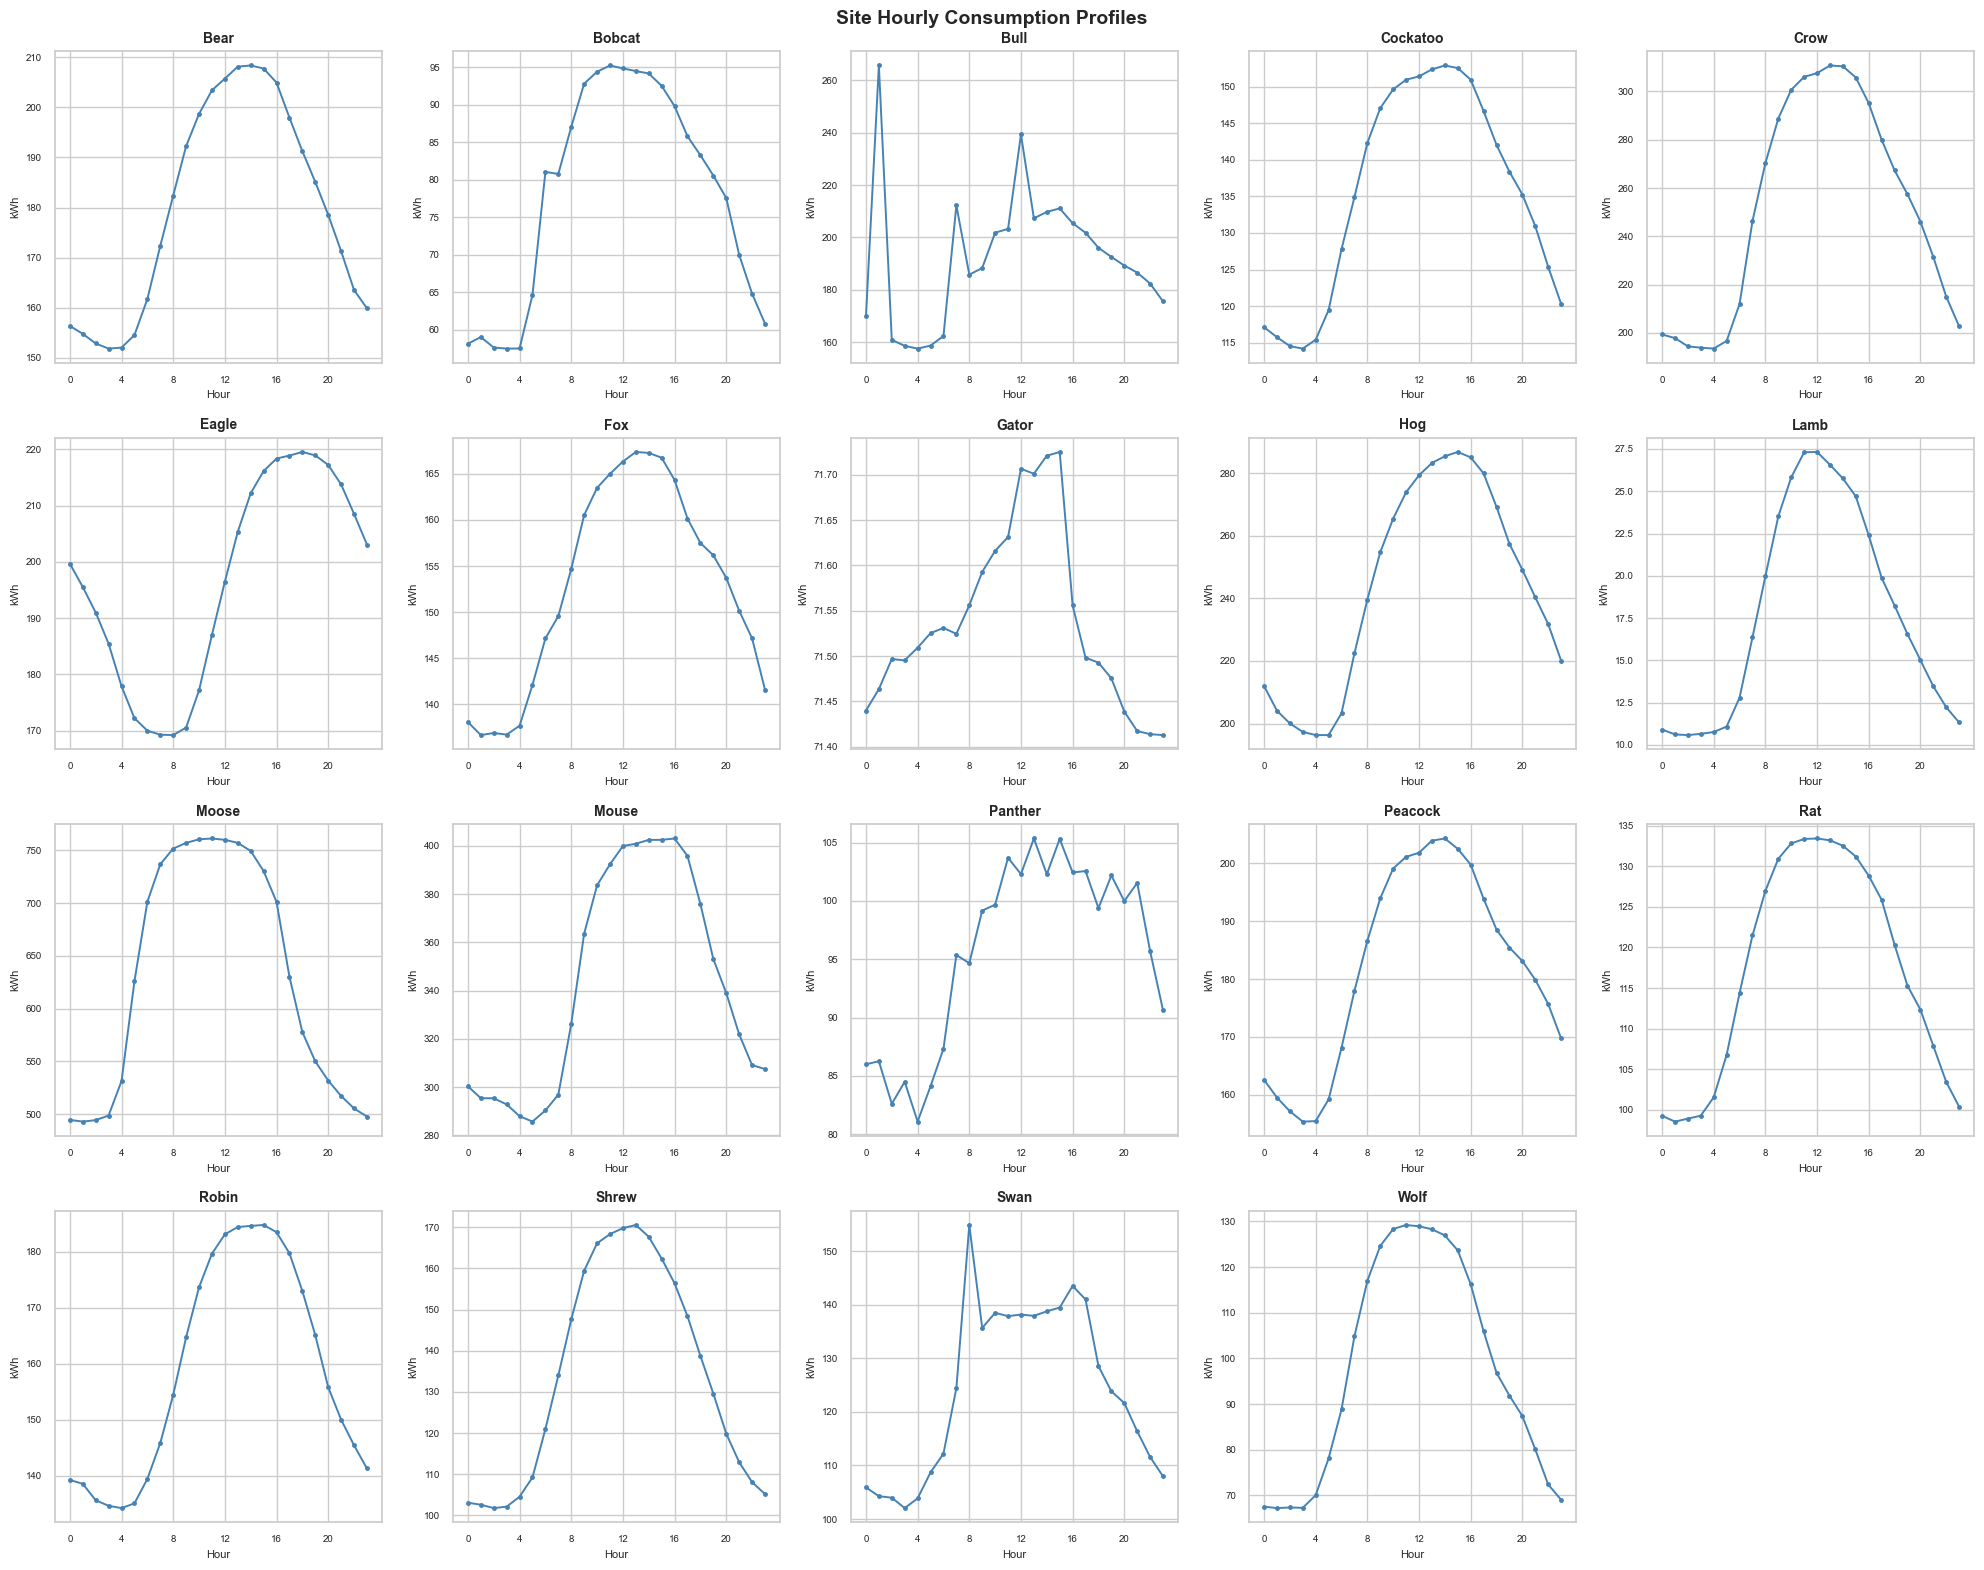

In [24]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = hourly_profiles[site]
    ax.plot(profile.index, profile.values, marker='o', markersize=2.5, linewidth=1.4, color='steelblue')
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.tick_params(labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

fig.suptitle('Site Hourly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

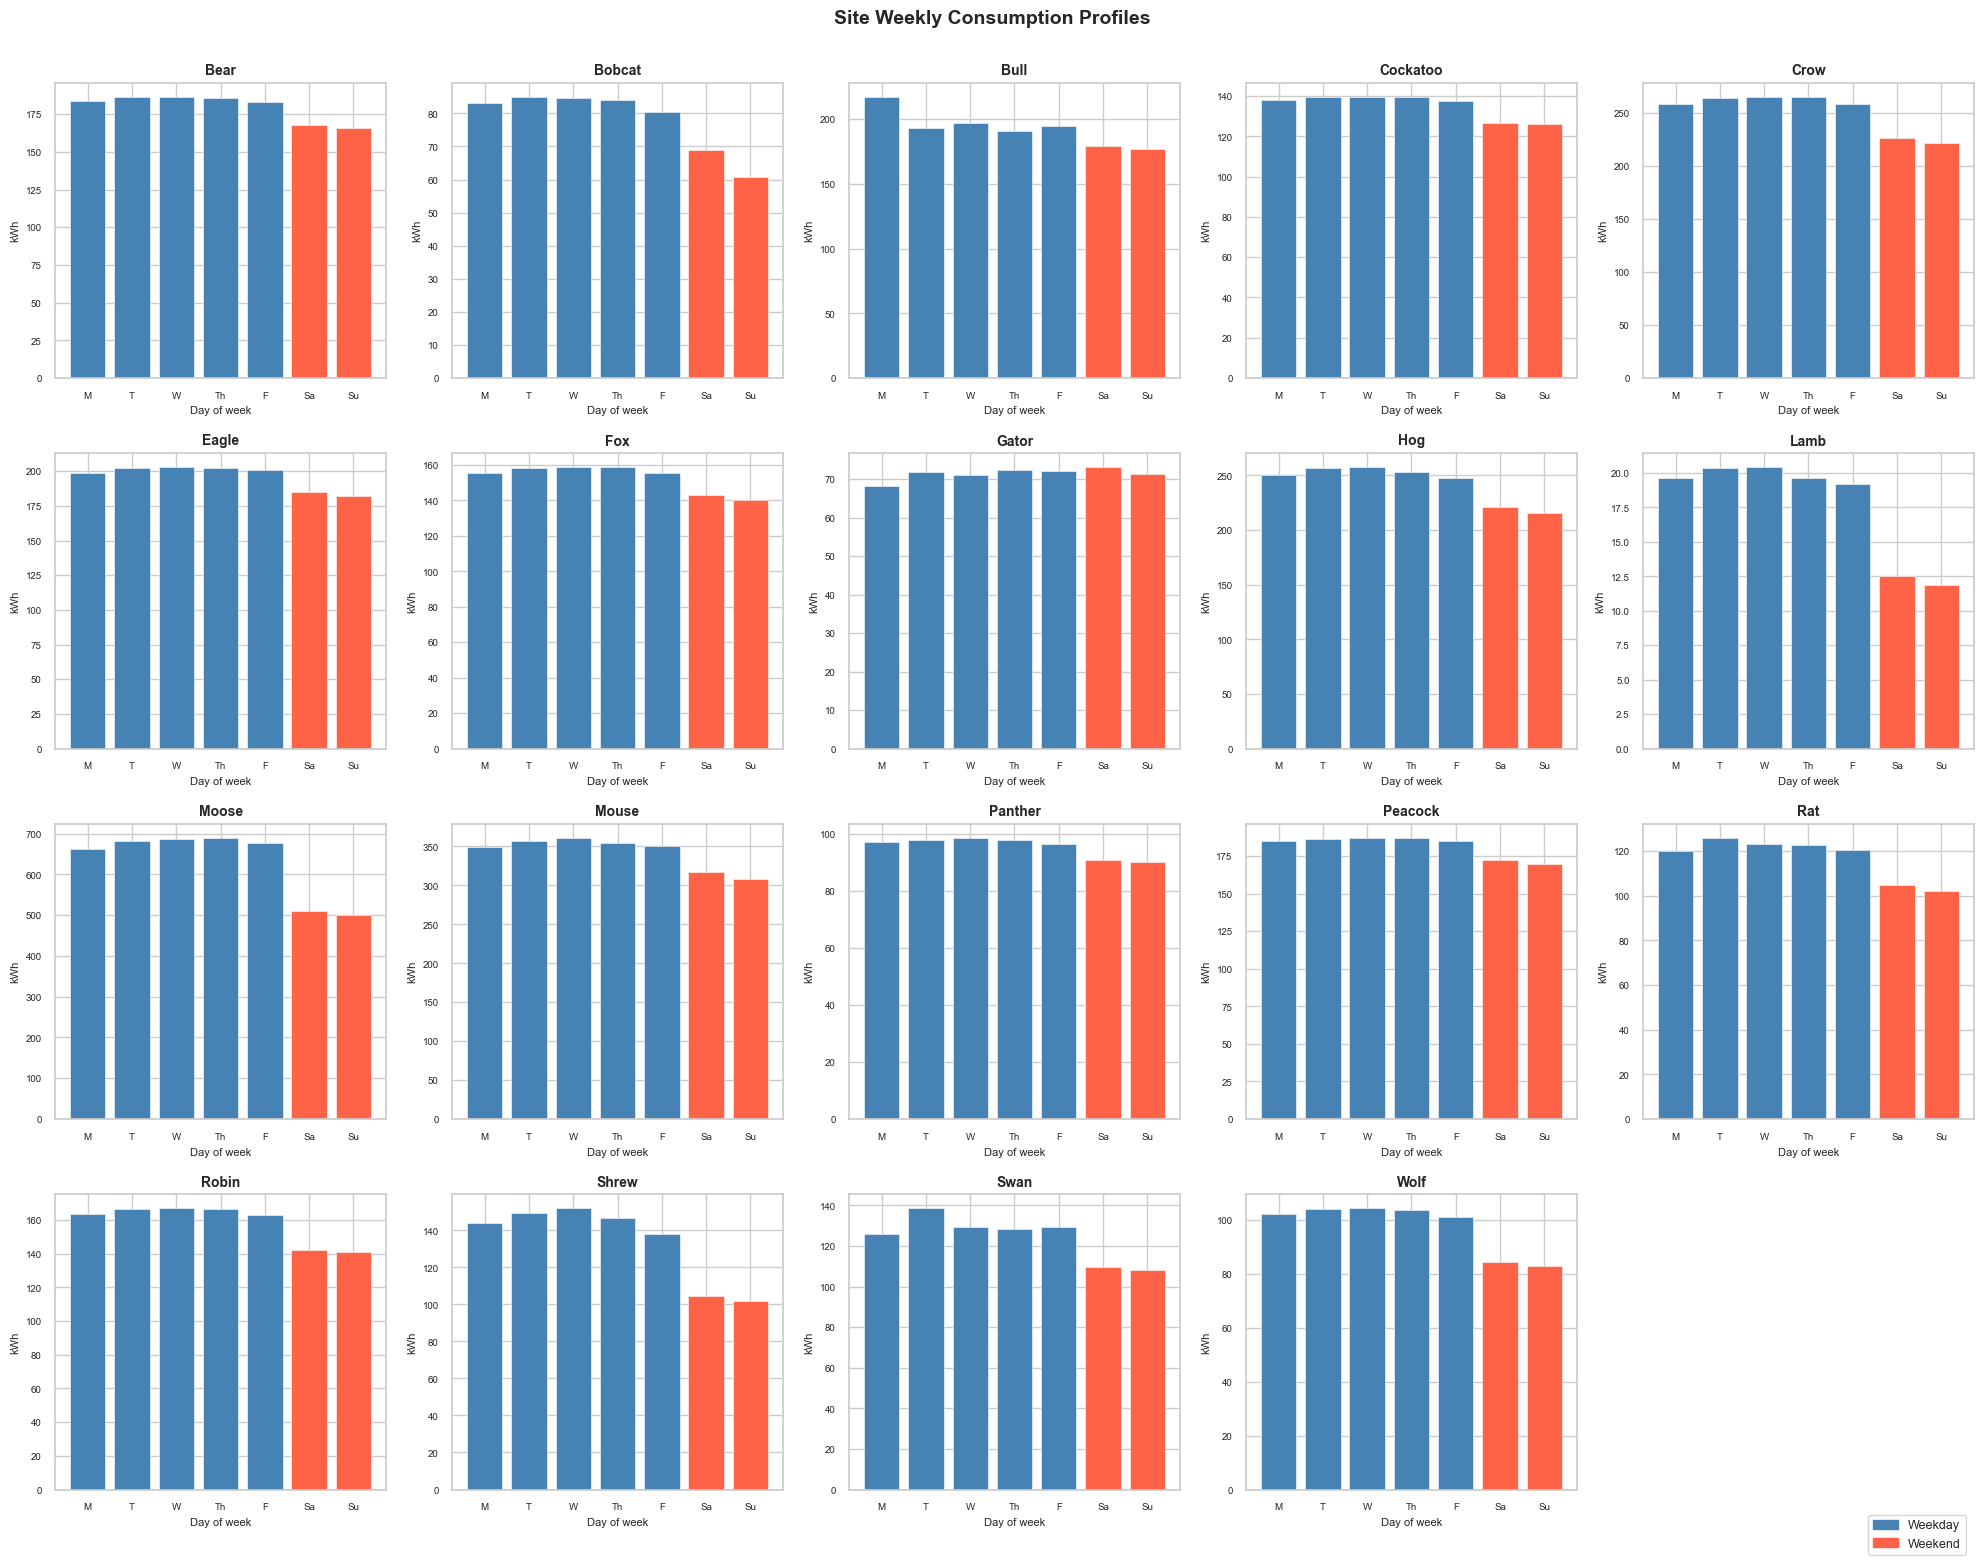

In [25]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

bar_colors = ['steelblue'] * 5 + ['tomato'] * 2  # Mon-Fri=blue, Sat-Sun=red

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = dow_profiles[site].reindex(range(7), fill_value=0)
    ax.bar(range(7), profile.values, color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Day of week', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(7))
    ax.set_xticklabels(['M', 'T', 'W', 'Th', 'F', 'Sa', 'Su'], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

from matplotlib.patches import Patch
legend_handles = [Patch(color='steelblue', label='Weekday'), Patch(color='tomato', label='Weekend')]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(0.99, 0.01), fontsize=9)

fig.suptitle('Site Weekly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

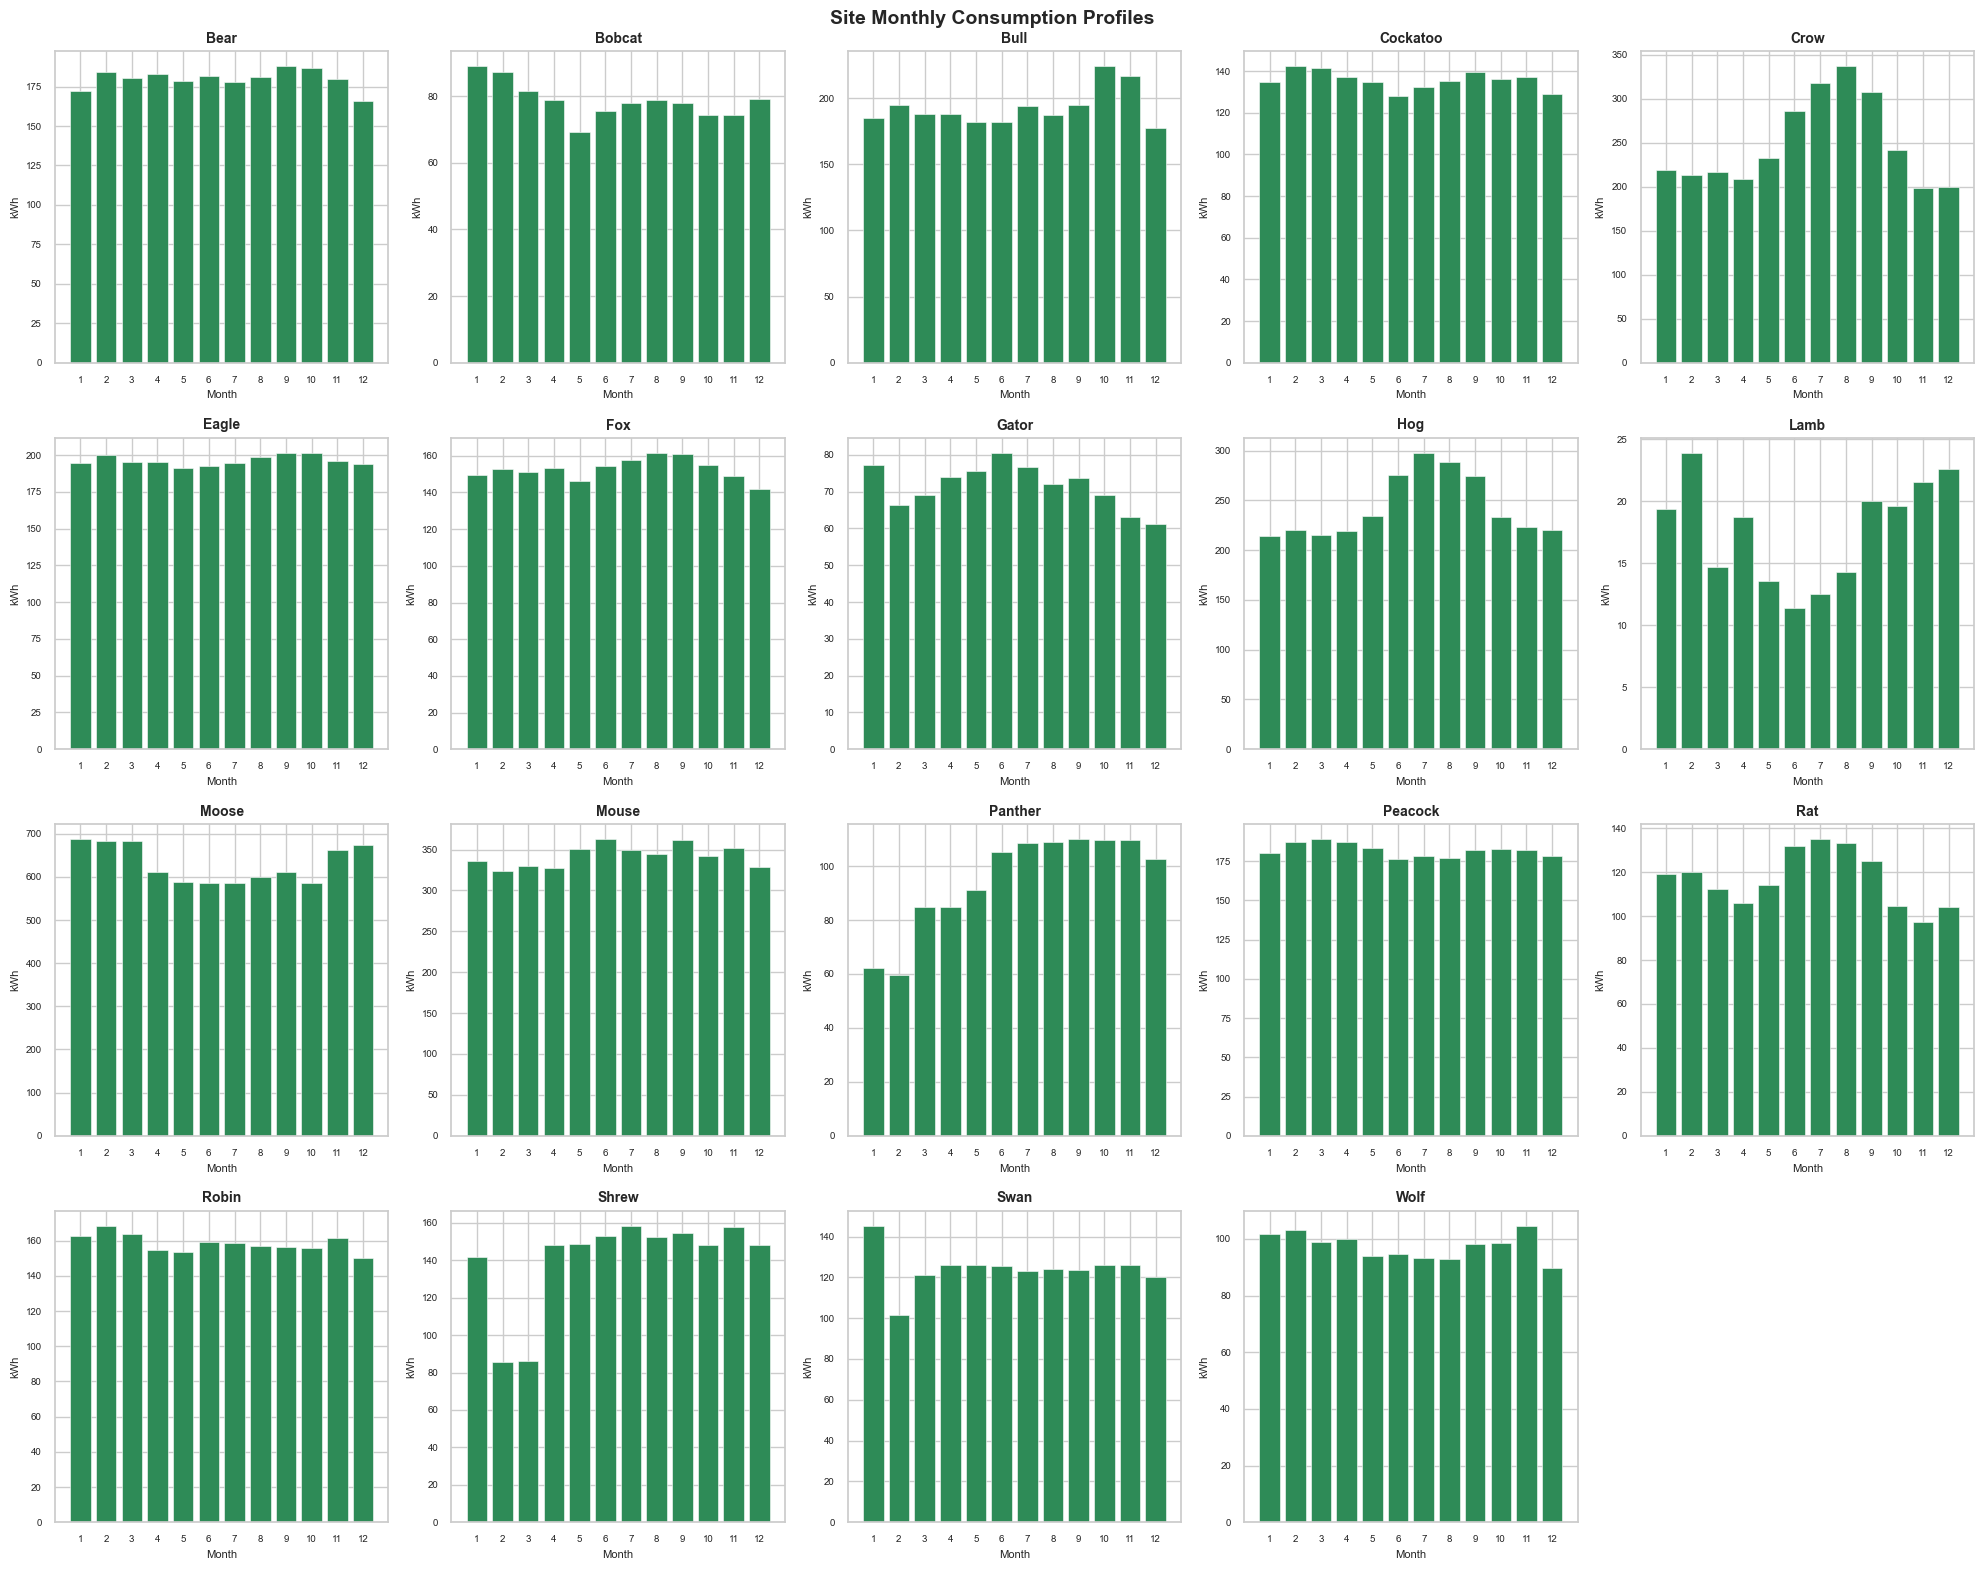

In [31]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = monthly_profiles[site].reindex(range(1, 13), fill_value=0)
    ax.bar(range(1, 13), profile.values, color='seagreen', edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Month', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

fig.suptitle('Site Monthly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

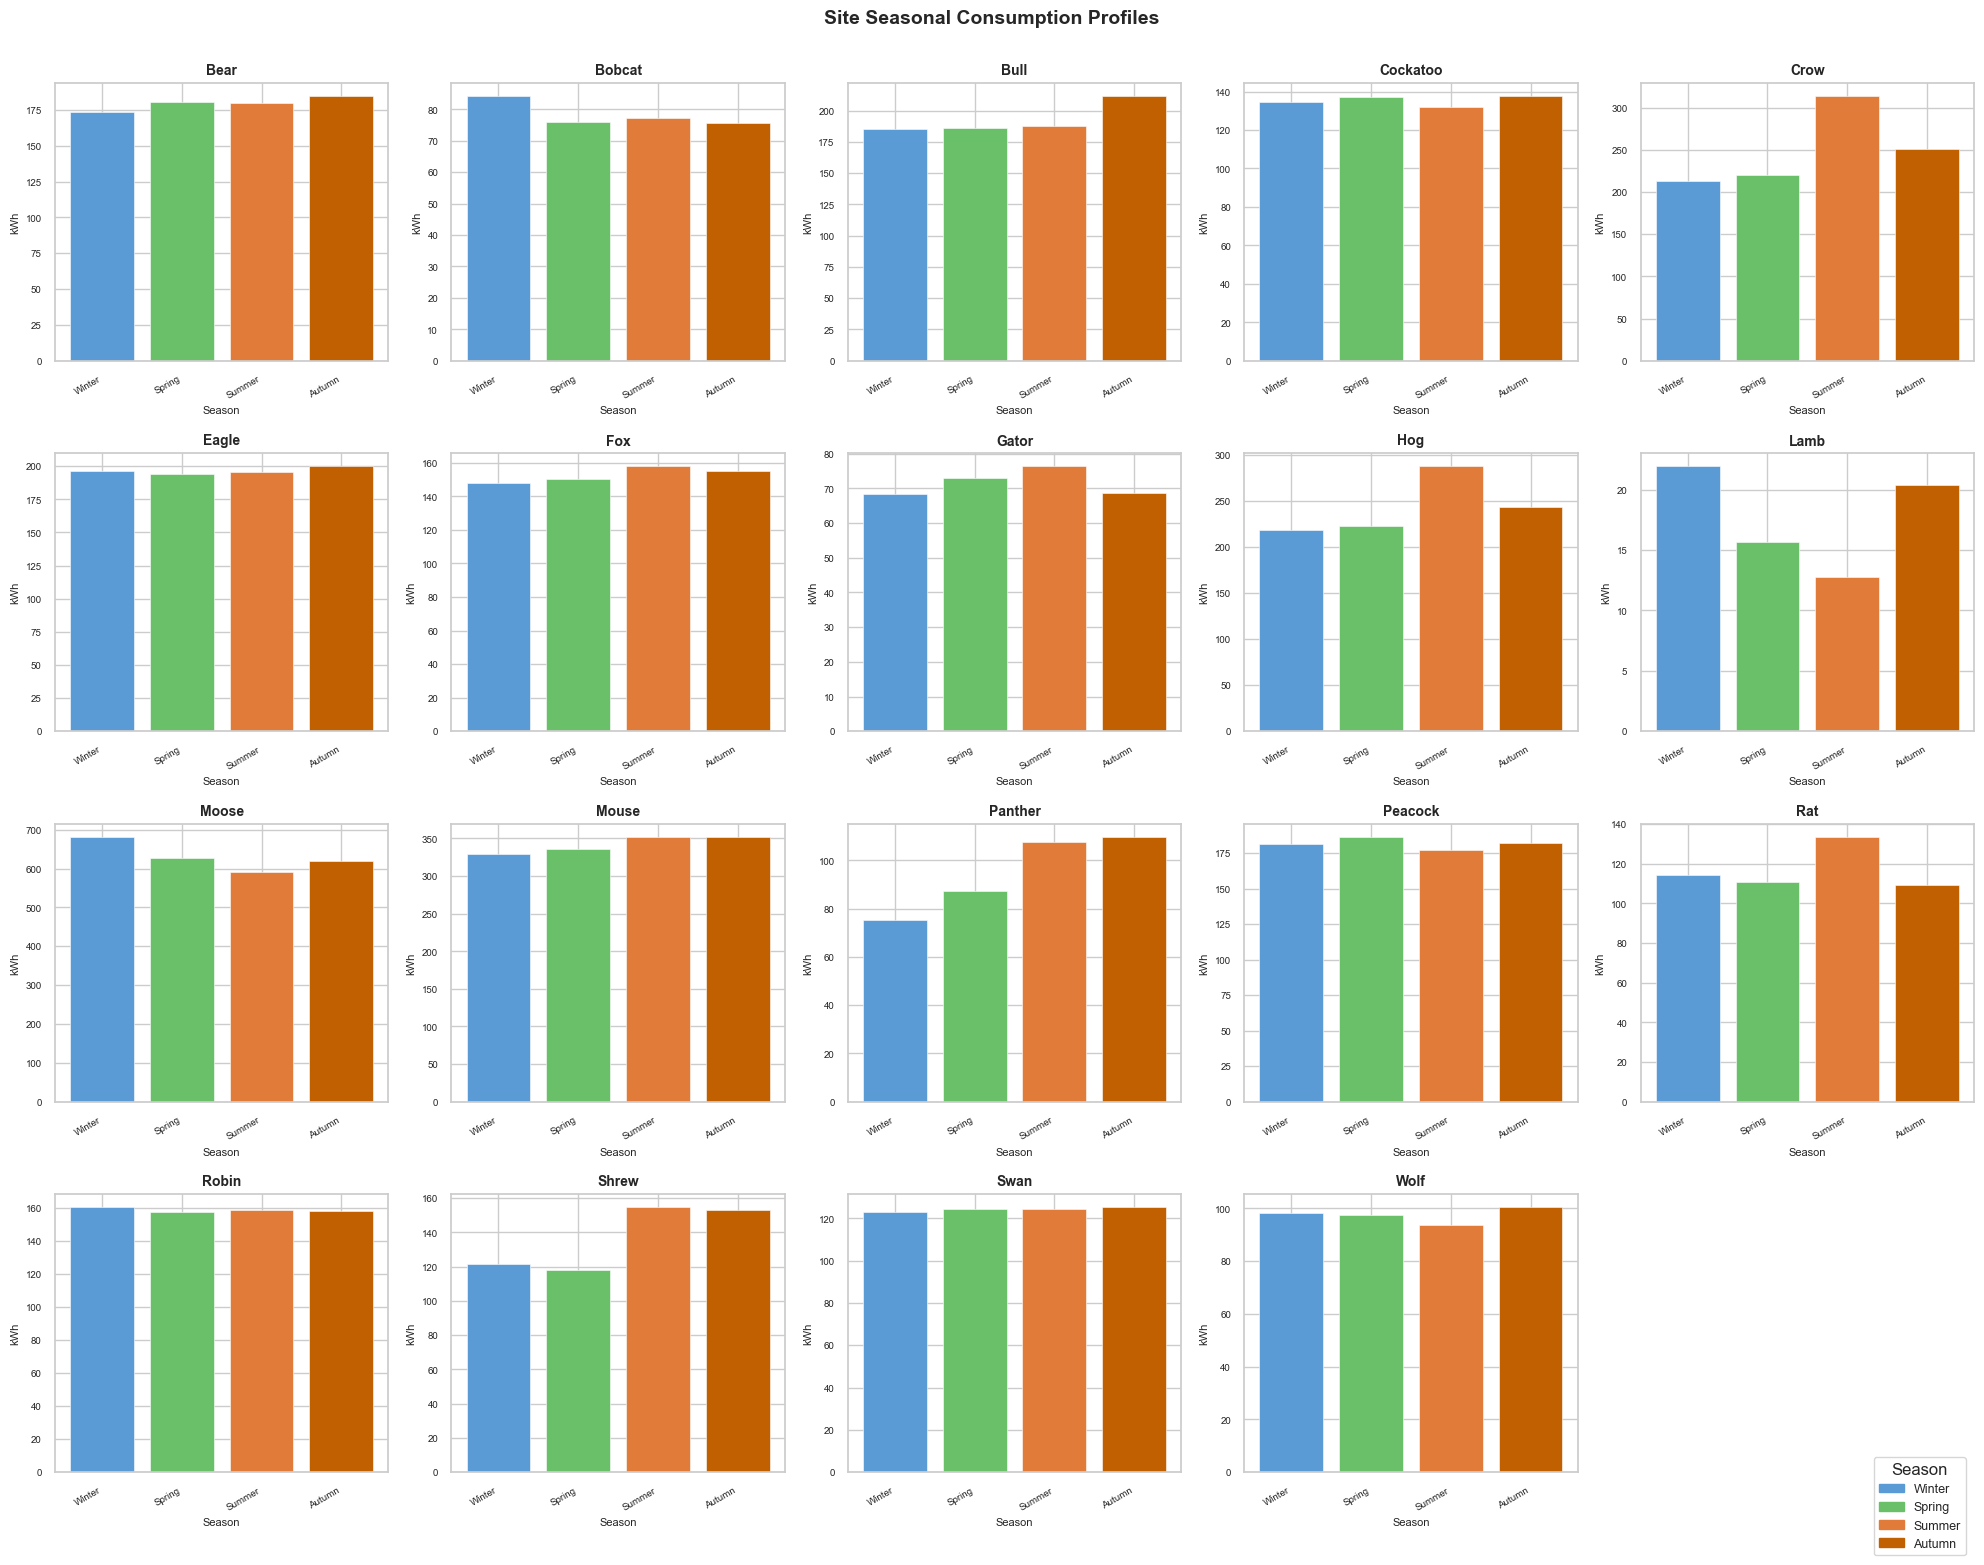

In [32]:
from matplotlib.patches import Patch

SEASON_MAP = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
SEASON_COLORS = {'Winter': '#5b9bd5', 'Spring': '#6abf69',
                 'Summer': '#e07b39', 'Autumn': '#c06000'}

def site_seasonal_profile(site):
    cols = site_to_blds[site]
    site_mean = elec_idx[cols].mean(axis=1)
    season_series = site_mean.index.month.map(SEASON_MAP)
    return site_mean.groupby(season_series).mean().reindex(SEASON_ORDER)

seasonal_profiles = {s: site_seasonal_profile(s) for s in sites}

NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = seasonal_profiles[site]
    colors = [SEASON_COLORS[s] for s in SEASON_ORDER]
    ax.bar(SEASON_ORDER, profile.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Season', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticklabels(SEASON_ORDER, fontsize=7, rotation=30, ha='right')
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

legend_handles = [Patch(color=SEASON_COLORS[s], label=s) for s in SEASON_ORDER]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(0.99, 0.01),
           fontsize=9, title='Season')

fig.suptitle('Site Seasonal Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

## 7. Site Metadata Profile

In [27]:
meta_matched = meta[meta['building_id'].isin(matched)].copy()

site_meta = meta_matched.groupby('site_id').agg(
    avg_sqm        = ('sqm', 'mean'),
    median_sqm     = ('sqm', 'median'),
    total_sqm      = ('sqm', 'sum'),
    avg_yearbuilt  = ('yearbuilt', 'mean'),
    top_usage      = ('primaryspaceusage', lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan),
).reset_index()

display(site_meta.style.format({'avg_sqm': '{:.0f}', 'median_sqm': '{:.0f}',
                                 'total_sqm': '{:,.0f}', 'avg_yearbuilt': '{:.1f}'}))

,site_id,avg_sqm,median_sqm,total_sqm,avg_yearbuilt,top_usage
0,Bear,8778,6357,"807,571",1954.2,Education
1,Bobcat,7032,6052,"246,104",nan,Education
2,Bull,13440,9435,"1,653,097",nan,Education
3,Cockatoo,7828,6132,"915,878",1962.3,Education
4,Crow,9714,8659,"48,571",nan,Education
5,Eagle,8727,6453,"925,109",nan,Office
6,Fox,9307,6635,"1,275,032",1975.2,Education
7,Gator,3017,743,"223,261",nan,Public services
8,Hog,12229,8520,"1,858,754",nan,Office
9,Lamb,3487,2173,"509,109",1960.9,Education


## 8. Site Building Type Mix

In [28]:
type_mix = meta_matched.groupby(['site_id', 'primaryspaceusage']).size().unstack(fill_value=0)
type_mix.index.name = 'site_id'

print('Building count by site and usage type:')
display(type_mix)

type_mix_pct = type_mix.div(type_mix.sum(axis=1), axis=0) * 100
print('\nNormalized percentage by site:')
display(type_mix_pct.style.format('{:.1f}%'))

Building count by site and usage type:


primaryspaceusage,Education,Entertainment/public assembly,Food sales and service,Healthcare,Lodging/residential,Manufacturing/industrial,Office,Other,Parking,Public services,Religious worship,Retail,Services,Technology/science,Utility,Warehouse/storage
site_id,,,,,,,,,,,,,,,,
Bear,67,9,0,0,4,0,0,0,3,6,0,0,0,2,1,0
Bobcat,17,4,0,0,3,0,5,3,0,1,0,0,0,1,0,1
Bull,63,17,0,0,19,0,17,0,0,2,0,0,5,0,0,0
Cockatoo,43,16,0,0,28,2,18,0,0,6,1,0,0,1,2,0
Crow,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Eagle,26,11,2,10,10,0,40,0,0,7,0,0,0,0,0,0
Fox,63,21,2,1,12,0,24,0,3,6,1,1,0,0,1,2
Gator,0,26,0,0,0,0,8,9,0,29,0,0,0,0,0,2
Hog,24,11,1,3,11,5,73,3,8,5,0,0,4,1,0,3



Normalized percentage by site:


primaryspaceusage,Education,Entertainment/public assembly,Food sales and service,Healthcare,Lodging/residential,Manufacturing/industrial,Office,Other,Parking,Public services,Religious worship,Retail,Services,Technology/science,Utility,Warehouse/storage
site_id,,,,,,,,,,,,,,,,
Bear,72.8%,9.8%,0.0%,0.0%,4.3%,0.0%,0.0%,0.0%,3.3%,6.5%,0.0%,0.0%,0.0%,2.2%,1.1%,0.0%
Bobcat,48.6%,11.4%,0.0%,0.0%,8.6%,0.0%,14.3%,8.6%,0.0%,2.9%,0.0%,0.0%,0.0%,2.9%,0.0%,2.9%
Bull,51.2%,13.8%,0.0%,0.0%,15.4%,0.0%,13.8%,0.0%,0.0%,1.6%,0.0%,0.0%,4.1%,0.0%,0.0%,0.0%
Cockatoo,36.8%,13.7%,0.0%,0.0%,23.9%,1.7%,15.4%,0.0%,0.0%,5.1%,0.9%,0.0%,0.0%,0.9%,1.7%,0.0%
Crow,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Eagle,24.5%,10.4%,1.9%,9.4%,9.4%,0.0%,37.7%,0.0%,0.0%,6.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Fox,46.0%,15.3%,1.5%,0.7%,8.8%,0.0%,17.5%,0.0%,2.2%,4.4%,0.7%,0.7%,0.0%,0.0%,0.7%,1.5%
Gator,0.0%,35.1%,0.0%,0.0%,0.0%,0.0%,10.8%,12.2%,0.0%,39.2%,0.0%,0.0%,0.0%,0.0%,0.0%,2.7%
Hog,15.8%,7.2%,0.7%,2.0%,7.2%,3.3%,48.0%,2.0%,5.3%,3.3%,0.0%,0.0%,2.6%,0.7%,0.0%,2.0%


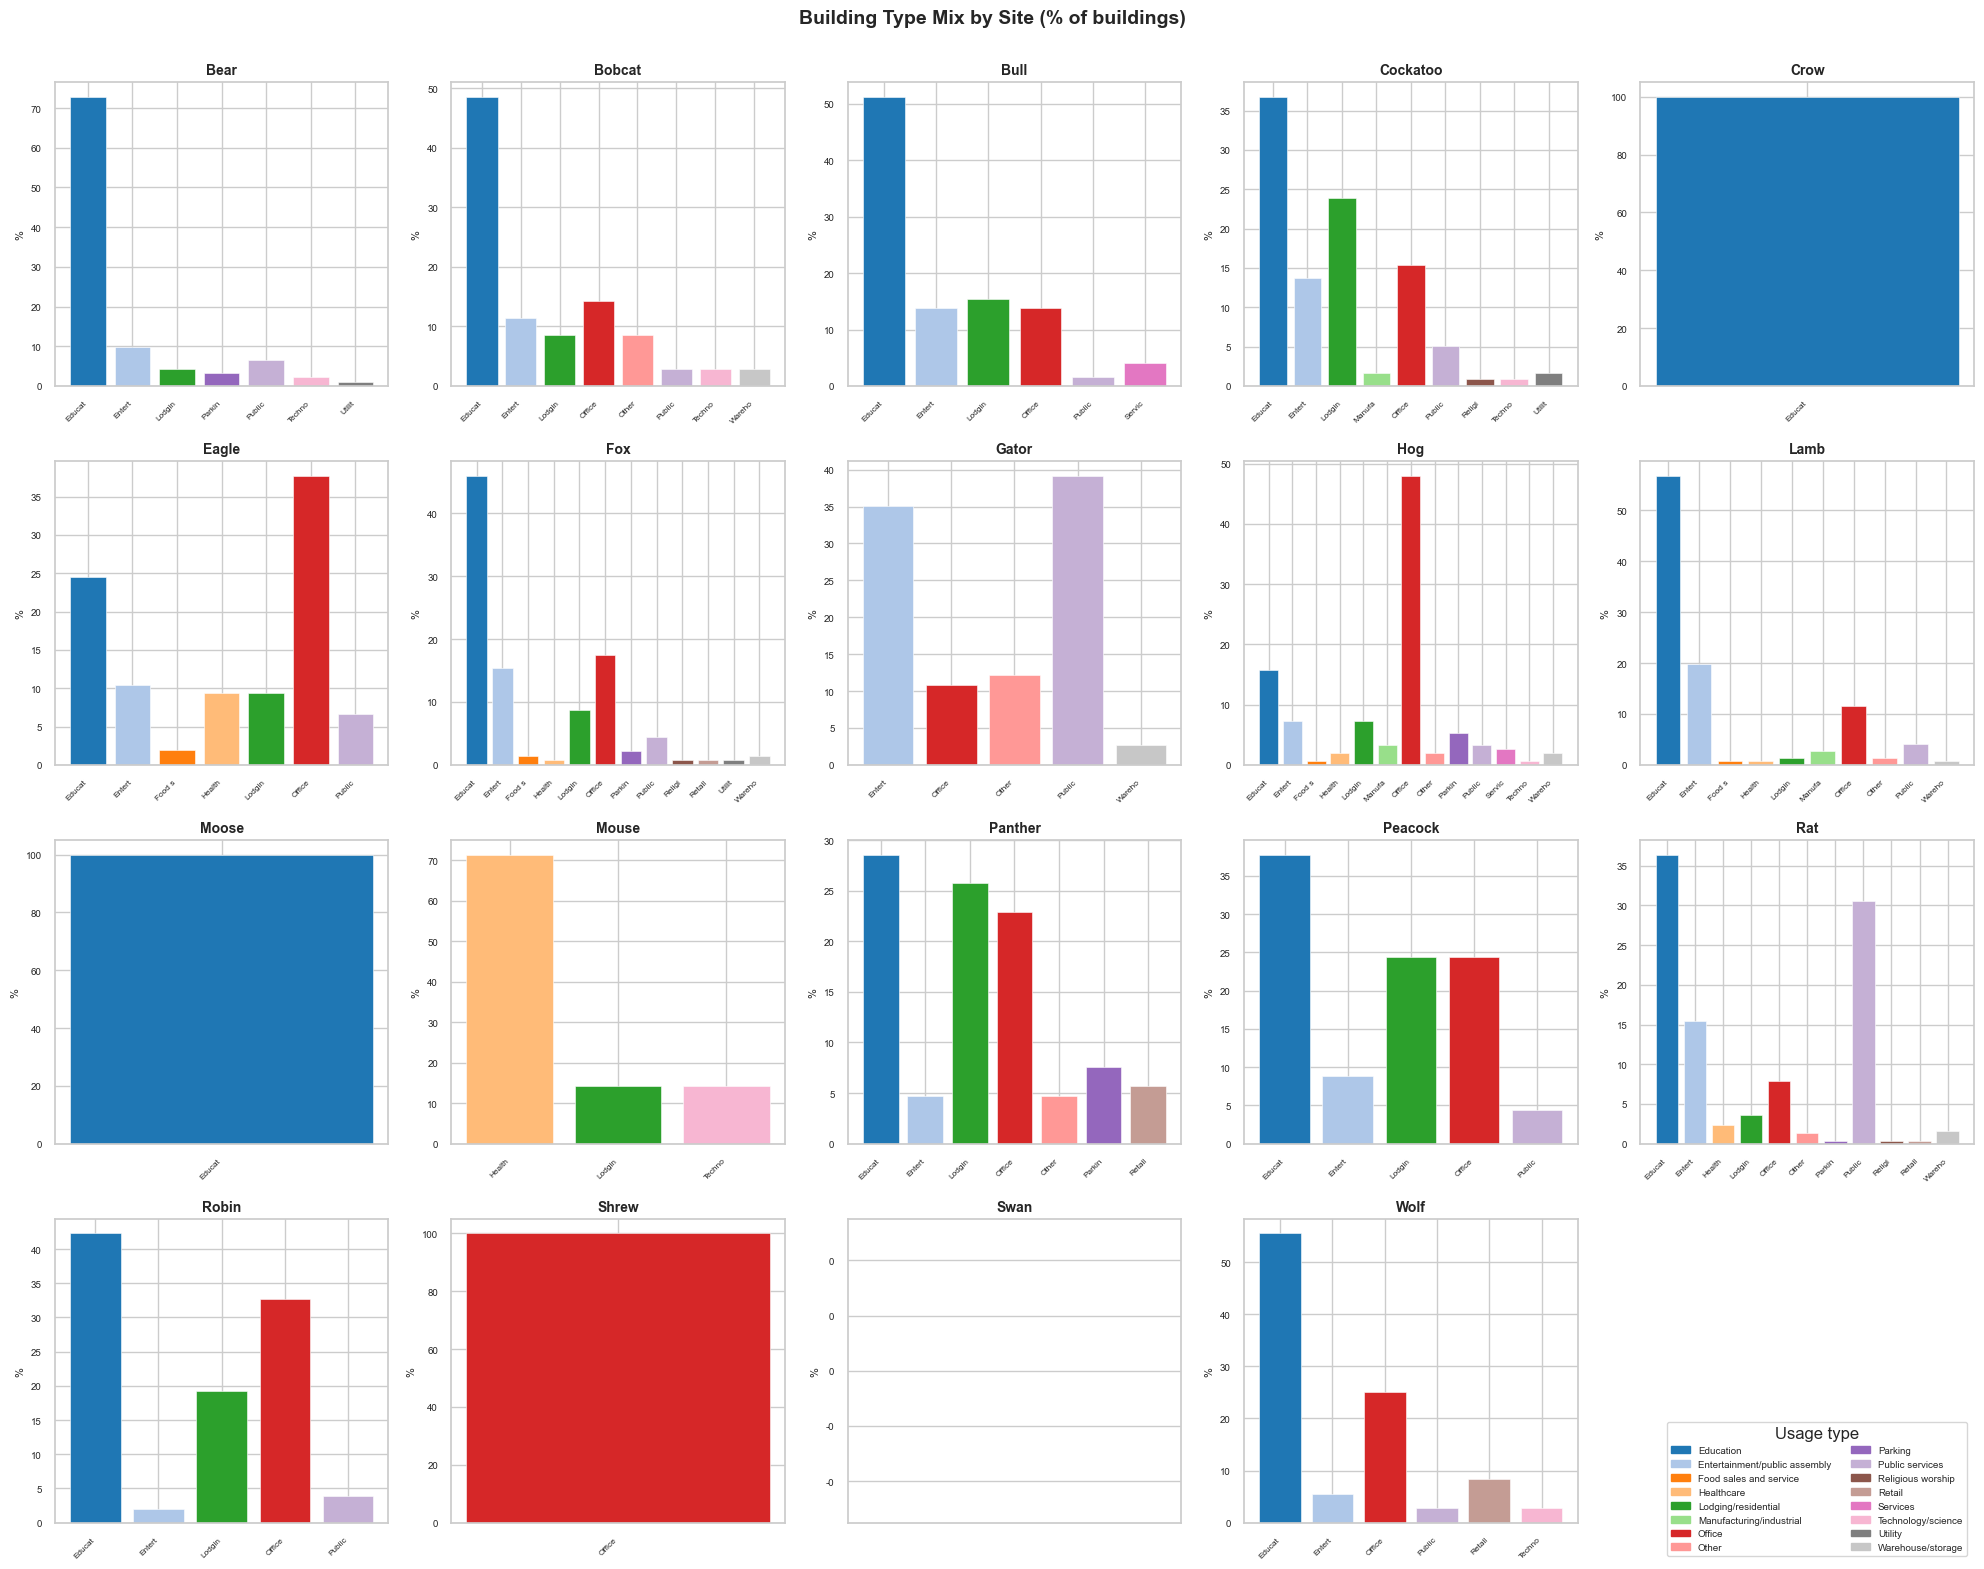

In [29]:
colors = plt.cm.tab20.colors
usage_types = list(type_mix_pct.columns)

NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16))
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    row = type_mix_pct.loc[site] if site in type_mix_pct.index else pd.Series(dtype=float)
    row = row[row > 0]
    ax.bar(range(len(row)), row.values,
           color=[colors[usage_types.index(u) % len(colors)] for u in row.index],
           edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_ylabel('%', fontsize=8)
    ax.set_xticks(range(len(row)))
    ax.set_xticklabels(
        [u[:6] for u in row.index],
        rotation=45, ha='right', fontsize=6
    )
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

# Shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors[k % len(colors)], label=u)
    for k, u in enumerate(usage_types)
]
fig.legend(handles=legend_patches, title='Usage type', fontsize=7,
           loc='lower right', bbox_to_anchor=(0.99, 0.01), ncol=2)

fig.suptitle('Building Type Mix by Site (% of buildings)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.0, 1, 0.98])
plt.show()

## 9. Summary Observations

### Stage 0.1
- **Which sites have the most buildings?** *(see Stage 0.2 §2)*
- **Which sites consume the most electricity?** *(see Stage 0.2 §3)*
- **Which sites have the highest missing rates?** *(see Stage 0.2 §4)*
- **Which sites have the highest zero rates?** *(see Stage 0.2 §4)*

### Stage 0.2
- **Which sites are most variable?** *(see §5 — highest CV)*
- **Are there signs of site-wide data quality problems?** *(see §4 — missing / zero / negative rates per site)*
- **Which sites may need special treatment in anomaly detection?** *(fill in after reviewing §3–§6)*

---
*These prompts should be filled in after running the notebook and reviewing the outputs above.*